In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.integrate as spi

0.45269321722152


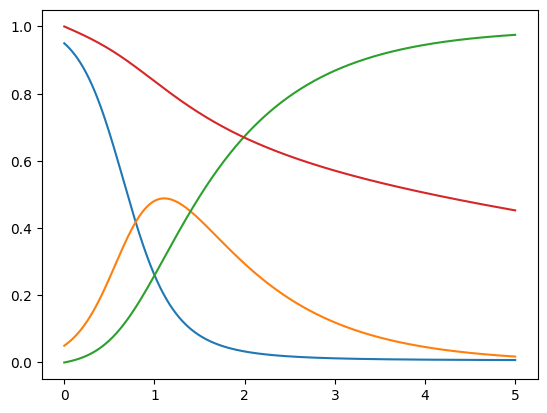

In [2]:
mu = 0.1
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0]) # Alive, dead,S,I,R
R0 = 5
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+3*u[1])*u[3]
    dudt[4] = mu*(1+3*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]

plt.plot(t, y0[:,0:4])
print(y0[999,3])

0.6065306448427146


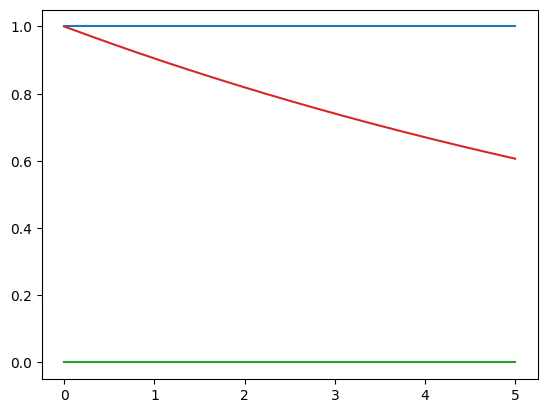

In [3]:
mu = 0.1
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([1,0.00,0,1,0]) # Alive, dead,S,I,R
R0 = 5
def ddt(u,t):
    dudt = np.zeros(5)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+3*u[1])*u[3]
    dudt[4] = mu*(1+3*u[1])*u[3]
    return dudt
    

t = np.linspace(0,5,1000)
y1 = spi.odeint(ddt, ic, t)

alive_no_pandemic = y1[:,3]

plt.plot(t, y1[:,0:4])
print(y1[999,3])

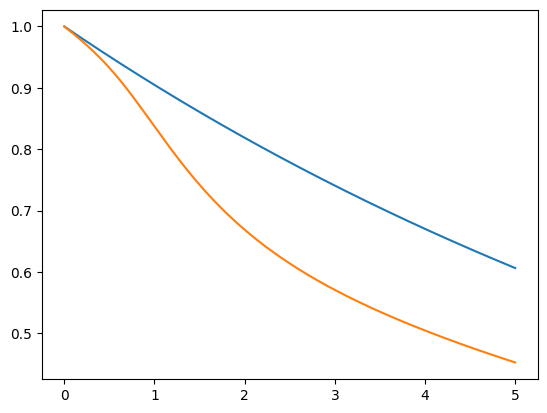

In [4]:
# plt.plot(t,alive_pandemic,alive_no_pandemic)
plt.plot(t, y1[:,3])
plt.plot(t, y0[:,3])
plt.show()

# Thiele's differential Equation for reserves 
$$\frac{d}{dt} {}_tV^{(i)} = \delta_t {}_tV^{(i)} - B_t^{(i)} - \sum_{j=0, j \neq i}^{m} \mu_{x+t}^{ij} \left( S_t^{(ij)} + {}_tV^{(j)} - {}_tV^{(i)} \right).$$

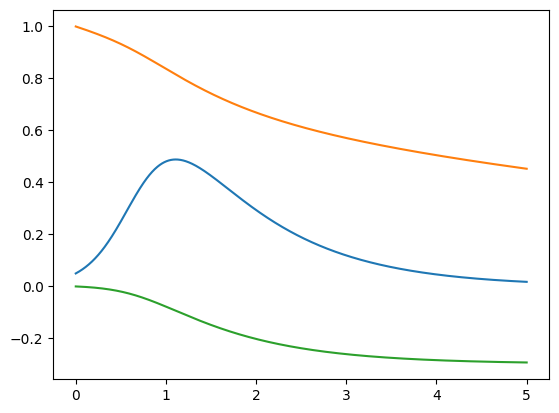

0.45269321722152


In [30]:
mu = 0.1
delta = 0.05 #force of interest
ddt = lambda p,t: np.array([-mu*p[0], mu*p[0]])
ic = np.array([0.95,0.05,0,1,0,0]) # Alive, dead,S,I,R, V(0)
R0 = 5
DB = 1 #death benefit
P = -mu*DB #premium calculated using equiv principle, assuming no pandemic
def ddt(u,t):
    dudt = np.zeros(6)
    dudt[0] = -R0 * u[0]*u[1]
    dudt[1] = R0*u[0] * u[1] - u[1]
    dudt[2] = u[1]
    dudt[3] = -mu*(1+3*u[1])*u[3]
    dudt[4] = mu*(1+3*u[1])*u[3]
    dudt[5] = delta*dudt[5] - P -mu*(1+3*u[1])*(DB -dudt[5])
    return dudt
    

t = np.linspace(0,5,1000)
y0 = spi.odeint(ddt, ic, t)

alive_pandemic = y0[:,3]


plt.plot(t, y0[:,1])
plt.plot(t, y0[:,3])
plt.plot(t, y0[:,5])
plt.show()
print(y0[999,3])

## Expected Present Value of Insurance

EPV of Benefits
$$EPV(\text{Benefit}) = DB \cdot \bar{A}_x$$
where $DB$ is the death benefit and $\bar{A}_x$ is the present value of a continuous whole life insurance of $\$1$
$$\bar{A}_x = \int_{0}^{\infty} v^t \cdot {}_t p_x \mu_{x+t} \, dt$$


EPV of Premiums
$$EPV(\text{Premium}) = P \cdot \bar{a}_x$$
Where $P$ is the annual premium, and $\bar{a}_x$ is the present value of a continuous whole life annuity paying $\$1$ yearly.
$$\bar{a}_x = \int_{0}^{\infty} v^t \cdot {}_t p_x \, dt$$


We investigate how a Pandemic affects the force of mortality $\mu_{x+t}$ and survival probability $_t p_x$ using the SIR model, in order to determine how a pandemic will affect the expected profitability of a life insurance product.


The non-dimensionalized SIR model
$$\begin{aligned}
\frac{ds^*}{dt} &= -\frac{\beta N}{\gamma} s^*i^*\\
\frac{di^*}{dt} &= \frac{\beta N}{\gamma} s^*i^* - i^*\\
\frac{dr^*}{dt} &=   i^* \\
&\qquad s^*(0) = s^*_0, \,\,
i^*(0) = i^*_0,\,\,
r^*(0) = r^*_0.
\end{aligned}
$$

Gives the proportion of the total population infected. We assume that higher infection in a population during a pandemic will translate to higher mortality rates for policyholders, so we link infection rate to to the mortality rate $\mu${x+t}$. 

$$\mu_{x+t} = \mu_0 (1 + x i^*)$$

we can use Kolmogorov's forward equation to calculate $_t p_x$ and integrate to find the difference in the EPV.

$$\frac{d}{dt} {}_t p_x^{ij} = \sum_{k=0, k \neq j}^{m} \left( {}_t p_x^{ik} \mu_{x+t}^{kj} - {}_t p_x^{ij} \mu_{x+t}^{jk} \right)$$

for whole life, this simplifies to
$$\frac{d}{dt} {}_t p_x^{00} = -\mu_{x+t} \cdot {}_t p_x^{00}